<style>
@media print {
    pre, code {
        white-space: pre-wrap !important;
        overflow-wrap: anywhere !important;
        word-wrap: break-word !important;
    }

    table {
        width: 100% !important;
        table-layout: fixed !important;
    }

    th, td {
        white-space: normal !important;
        overflow-wrap: anywhere !important;
        word-wrap: break-word !important;
        font-size: 9pt !important;
    }
}
</style>

**Name**: Casey Le  
**GitHub**: parakeet89  
**USC ID**: 8489799178

<center><h1>Le_Casey_HW1</h1></center>
<br>
<center><font size="4">Vertebral Column Data</font></center>

### (a) Download Data

Package imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neighbors import KNeighborsClassifier

Get the Vertebral Column Data Set

In [2]:
df = pd.read_csv('../data/vertebral_column_data/column_2c.dat', sep=r"\s+", header=None)

Change column indexes to column names

In [3]:
columns = ["pelvic_incidence", "pelvic_tilt", "lumbar_lordosis_angle", "sacral_slope", "pelvic_radius", "spondylolisthesis_grade", "Class"]
df.columns = columns

Convert labels to 0 and 1 for Class column

In [4]:
df["Class"] = [1 if x == "AB" else 0 for x in df["Class"]]

In [5]:
df

,pelvic_incidence,pelvic_tilt,lumbar_lordosis_angle,sacral_slope,pelvic_radius,spondylolisthesis_grade,Class
0,63.03,22.55,39.61,40.48,98.67,-0.25,1
1,39.06,10.06,25.02,29.00,114.41,4.56,1
2,68.83,22.22,50.09,46.61,105.99,-3.53,1
3,69.30,24.65,44.31,44.64,101.87,11.21,1
4,49.71,9.65,28.32,40.06,108.17,7.92,1
...,...,...,...,...,...,...,...
305,47.90,13.62,36.00,34.29,117.45,-4.25,0
306,53.94,20.72,29.22,33.22,114.37,-0.42,0
307,61.45,22.69,46.17,38.75,125.67,-2.71,0
308,45.25,8.69,41.58,36.56,118.55,0.21,0


### (b) Pre-Processing and Exploratory Data Analysis

#### i. Scatterplots

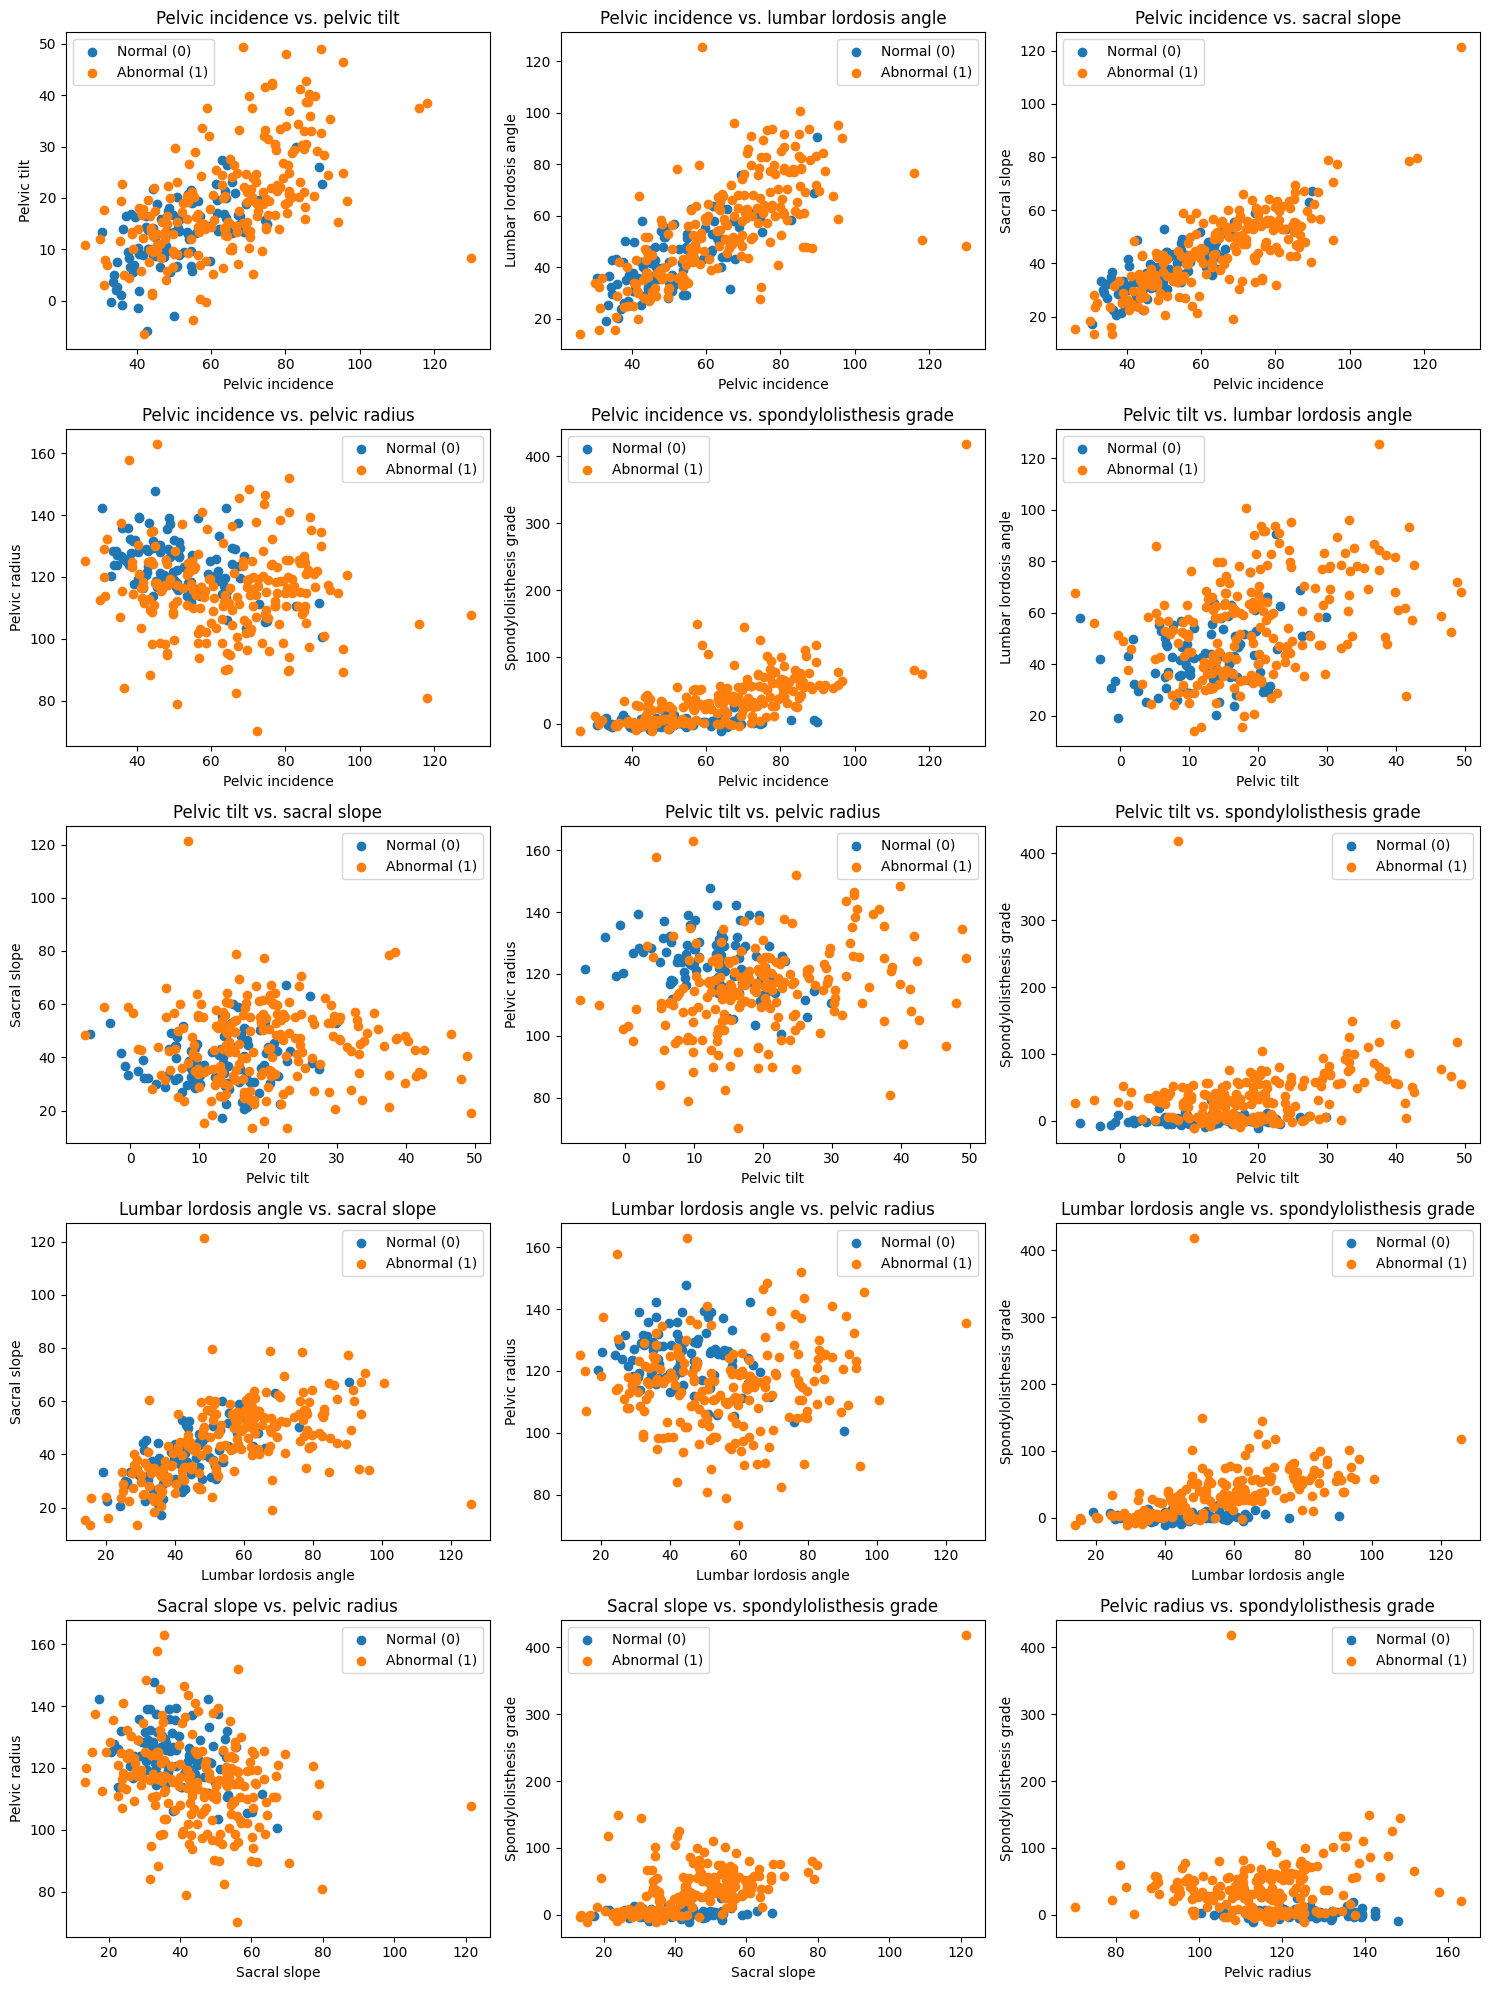

In [6]:
columns = ['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'spondylolisthesis_grade']
labels = ['Pelvic incidence', 'Pelvic tilt', 'Lumbar lordosis angle', 'Sacral slope', 'Pelvic radius', 'Spondylolisthesis grade']

fig, axes = plt.subplots(5, 3, figsize=(15, 20))

plot_num = 0

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        ax = axes.flat[plot_num]
        ax.scatter(df[df['Class'] == 0][columns[i]],df[df['Class'] == 0][columns[j]],label='Normal (0)')
        ax.scatter(df[df['Class'] == 1][columns[i]],df[df['Class'] == 1][columns[j]],label='Abnormal (1)')
        ax.legend()
        ax.set_title(f'{labels[i]} vs. {labels[j].lower()}')
        ax.set_xlabel(labels[i])
        ax.set_ylabel(labels[j])
        plot_num += 1

plt.tight_layout()
plt.show()

#### ii. Boxplots

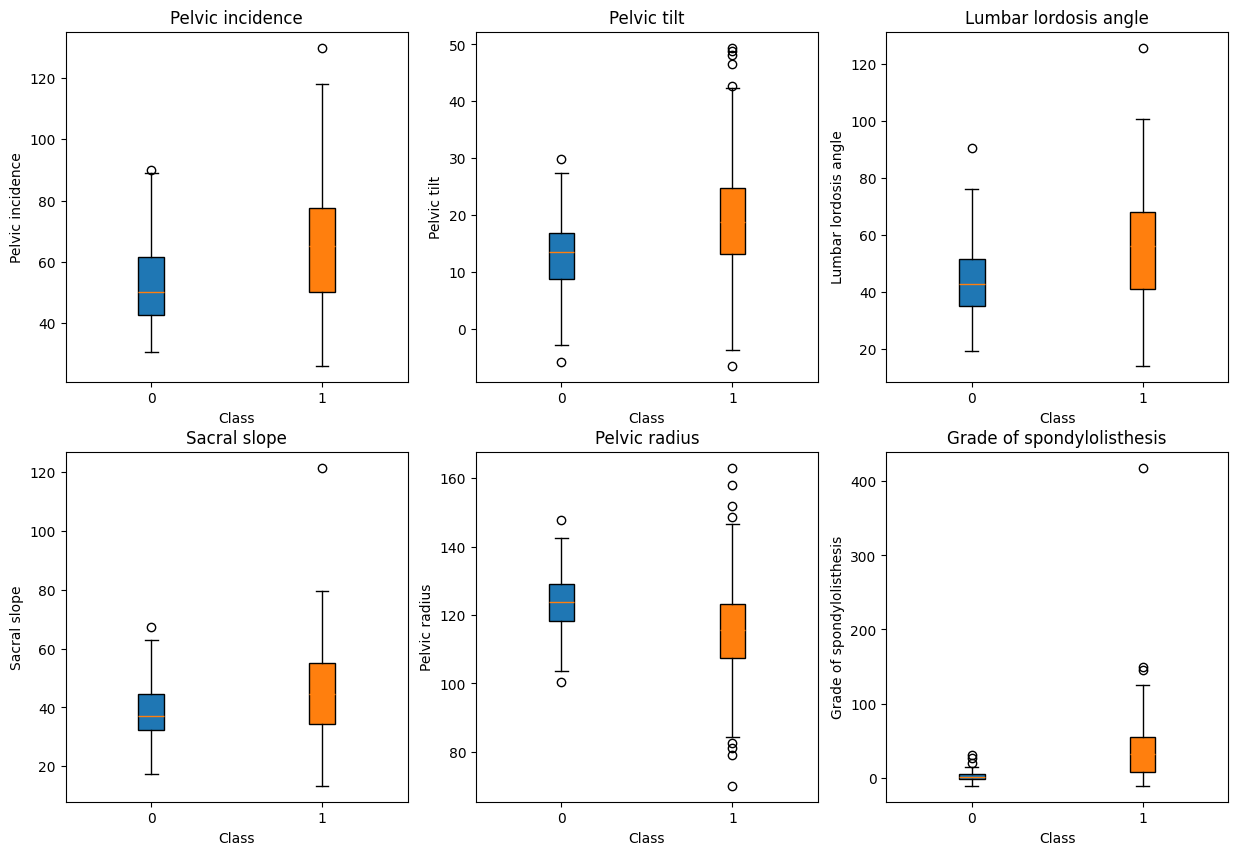

In [7]:
labels = ['0', '1']
colors = ['tab:blue', 'tab:orange']

plt.figure(figsize=(15, 10))

plt.subplot(2, 3, 1)
bplot1 = plt.boxplot([df[df['Class'] == 0]['pelvic_incidence'], df[df['Class'] == 1]['pelvic_incidence']], tick_labels=labels, patch_artist=True)
for patch, color in zip(bplot1['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Pelvic incidence')
plt.xlabel('Class')
plt.ylabel('Pelvic incidence')

plt.subplot(2, 3, 2)
bplot2 = plt.boxplot([df[df['Class'] == 0]['pelvic_tilt'], df[df['Class'] == 1]['pelvic_tilt']], tick_labels=labels, patch_artist=True)
for patch, color in zip(bplot2['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Pelvic tilt')
plt.xlabel('Class')
plt.ylabel('Pelvic tilt')

plt.subplot(2, 3, 3)
bplot3 = plt.boxplot([df[df['Class'] == 0]['lumbar_lordosis_angle'], df[df['Class'] == 1]['lumbar_lordosis_angle']], tick_labels=labels, patch_artist=True)
for patch, color in zip(bplot3['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Lumbar lordosis angle')
plt.xlabel('Class')
plt.ylabel('Lumbar lordosis angle')

plt.subplot(2, 3, 4)
bplot4 = plt.boxplot([df[df['Class'] == 0]['sacral_slope'], df[df['Class'] == 1]['sacral_slope']], tick_labels=labels, patch_artist=True)
for patch, color in zip(bplot4['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Sacral slope')
plt.xlabel('Class')
plt.ylabel('Sacral slope')

plt.subplot(2, 3, 5)
bplot5 = plt.boxplot([df[df['Class'] == 0]['pelvic_radius'], df[df['Class'] == 1]['pelvic_radius']], tick_labels=labels, patch_artist=True)
for patch, color in zip(bplot5['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Pelvic radius')
plt.xlabel('Class')
plt.ylabel('Pelvic radius')

plt.subplot(2, 3, 6)
bplot6 = plt.boxplot([df[df['Class'] == 0]['spondylolisthesis_grade'], df[df['Class'] == 1]['spondylolisthesis_grade']], tick_labels=labels, patch_artist=True)
for patch, color in zip(bplot6['boxes'], colors):
    patch.set_facecolor(color)
plt.title('Grade of spondylolisthesis')
plt.xlabel('Class')
plt.ylabel('Grade of spondylolisthesis')

plt.show()

#### iii. Split Data Set

In [8]:
train = pd.concat([df[df.Class == 0][:70], df[df.Class == 1][:140]])
test = pd.concat([df[df.Class == 0][70:], df[df.Class == 1][140:]])

### (c) Classification

#### i. Euclidean Metric

In [9]:
from sklearn.neighbors import KNeighborsClassifier

# Separate train DataFrame into features and target
X_train = train[['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'spondylolisthesis_grade']]
y_train = train['Class']

# Do the same thing to test
X_test = test[['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'spondylolisthesis_grade']]
y_test = test['Class']

# Create a KNeighborsClassifier object
knn = KNeighborsClassifier(metric='euclidean')

# Fit the KNN classifier to the training data
model = knn.fit(X_train, y_train)

#### ii. Test Data

In [10]:
train_errors = []
test_errors = []
k_values = list(range(208, 0, -3))

for k in k_values:

    # Create and fit the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    knn.fit(X_train, y_train)

    # Predict the training and test classes
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate the training and test error rates
    train_error = 1 - knn.score(X_train, y_train)
    test_error = 1 - knn.score(X_test, y_test)

    # Store errors for each value of k
    train_errors.append(train_error)
    test_errors.append(test_error)

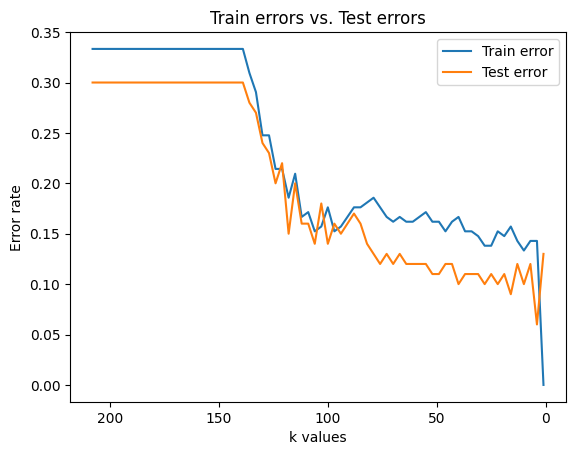

In [11]:
plt.plot(k_values, train_errors, label='Train error')
plt.plot(k_values, test_errors, label='Test error')
plt.title('Train errors vs. Test errors')
plt.xlabel('k values')
plt.ylabel('Error rate')
plt.gca().invert_xaxis()
plt.legend()

plt.show()

In [12]:
k_star = k_values[test_errors.index(min(test_errors))]
print('k* =', k_star, 'is the most suitable k among all k_values tested.')

k* = 4 is the most suitable k among all k_values tested.


In [13]:
knn_star = KNeighborsClassifier(n_neighbors=k_star, metric='euclidean')
knn_star.fit(X_train, y_train)
y_test_pred_star = knn_star.predict(X_test)

In [14]:
from sklearn.metrics import confusion_matrix, precision_score, f1_score

print('Confusion matrix:\n', confusion_matrix(y_test, y_test_pred_star))

Confusion matrix:
 [[25  5]
 [ 1 69]]


In [15]:
cm = confusion_matrix(y_test, y_test_pred_star)
tn, fp, fn, tp = cm.ravel()
true_positive_rate = tp / (tp + fn)
true_negative_rate = tn / (tn + fp)
print('True positive rate:', f"{true_positive_rate:.4f}")
print('True negative rate:', f"{true_negative_rate:.4f}")

True positive rate: 0.9857
True negative rate: 0.8333


In [16]:
print('Precision score:', f"{precision_score(y_test, y_test_pred_star):.4f}")

Precision score: 0.9324


In [17]:
print('F1 score:', f"{f1_score(y_test, y_test_pred_star):.4f}")

F1 score: 0.9583


#### iii. Learning Curve

In [18]:
n_values = list(range(10, 211, 10))
n_test_errors = []

for n in n_values:
    class_0_n = n // 3
    class_1_n = n - class_0_n
    n_train = pd.concat([train[train.Class == 0][:class_0_n], train[train.Class == 1][:class_1_n]])
    
    # Separate the smaller training set into features and target
    X_n_train = n_train[['pelvic_incidence', 'pelvic_tilt', 'lumbar_lordosis_angle', 'sacral_slope', 'pelvic_radius', 'spondylolisthesis_grade']]
    y_n_train = n_train['Class']

    # k starts at 1 and increases by 5
    k_values_n = list(range(1, n, 5))
    
    # Store the test error for each k for this particular n
    test_errors_n = []

    for k in k_values_n:
        knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
        knn.fit(X_n_train, y_n_train)

        test_error = 1 - knn.score(X_test, y_test)
        test_errors_n.append(test_error)

    # Store only the best test error for this n
    n_test_errors.append(min(test_errors_n))

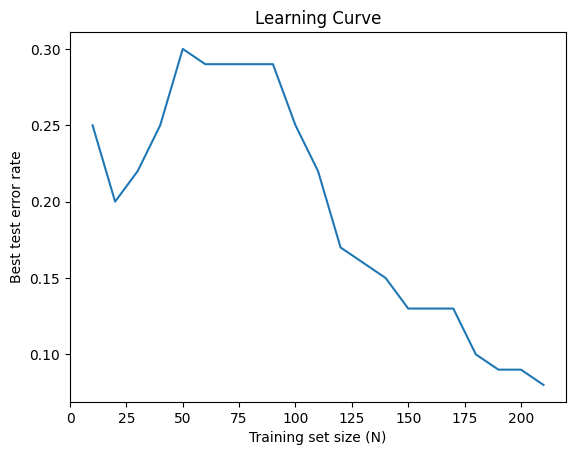

In [19]:
plt.plot(n_values, n_test_errors)
plt.xlabel('Training set size (N)')
plt.ylabel('Best test error rate')
plt.title('Learning Curve')
plt.show()

### (d) Other Metrics

#### i. Minkowski Distance.

##### A. Manhattan Distance with p = 1.

In [20]:
manhattan_train_errors = []
manhattan_test_errors = []
k_values = list(range(1, 197, 5))

for k in k_values:

    # Create and fit the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', p=1)
    knn.fit(X_train, y_train)

    # Predict the training and test classes
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate the training and test error rates
    train_error = 1 - knn.score(X_train, y_train)
    test_error = 1 - knn.score(X_test, y_test)

    # Store errors for each value of k
    manhattan_train_errors.append(train_error)
    manhattan_test_errors.append(test_error)

In [21]:
k_star_manhattan = k_values[manhattan_test_errors.index(min(manhattan_test_errors))]
print('k* =', k_star_manhattan, 'is the most suitable k among all k_values tested under Manhattan Distance with p = 1.')

k* = 6 is the most suitable k among all k_values tested under Manhattan Distance with p = 1.


##### B. With log10(p) in {0.1, 0.2, 0.3, ... ,1}.

In [22]:
minkowski_train_errors = []
minkowski_test_errors = []

log10_p_values = np.arange(0.1, 1.1, 0.1)
p_values = 10 ** log10_p_values

for p in p_values:

    # Create and fit the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k_star_manhattan, metric='minkowski', p=p)
    knn.fit(X_train, y_train)

    # Predict the training and test classes
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate the training and test error rates
    train_error = 1 - knn.score(X_train, y_train)
    test_error = 1 - knn.score(X_test, y_test)

    # Store errors for each value of p
    minkowski_train_errors.append(train_error)
    minkowski_test_errors.append(test_error)

In [23]:
best_log10_p = log10_p_values[minkowski_test_errors.index(min(minkowski_test_errors))]
print('log10(p) =', f"{best_log10_p:.4f}", 'is the most suitable log10(p) among all values tested under Minkowski distance with k =', k_star_manhattan)

log10(p) = 0.6000 is the most suitable log10(p) among all values tested under Minkowski distance with k = 6


##### C. Chebyshev Distance With p -> infinity.

In [24]:
chebyshev_train_errors = []
chebyshev_test_errors = []
k_values = list(range(1, 197, 5))

for k in k_values:

    # Create and fit the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='chebyshev')
    knn.fit(X_train, y_train)

    # Predict the training and test classes
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate the training and test error rates
    train_error = 1 - knn.score(X_train, y_train)
    test_error = 1 - knn.score(X_test, y_test)

    # Store errors for each value of k
    chebyshev_train_errors.append(train_error)
    chebyshev_test_errors.append(test_error)

In [25]:
k_star_chebyshev = k_values[chebyshev_test_errors.index(min(chebyshev_test_errors))]
print('k* =', k_star_chebyshev, 'is the most suitable k among all k_values tested under Chebyshev Distance with p -> ∞.')

k* = 16 is the most suitable k among all k_values tested under Chebyshev Distance with p -> ∞.


#### ii. Mahalanobis Distance.

In [26]:
cov_matrix = np.cov(X_train, rowvar=False)
inverse_cov_matrix = np.linalg.inv(cov_matrix)

mahalanobis_train_errors = []
mahalanobis_test_errors = []
k_values = list(range(1, 197, 5))

for k in k_values:

    # Create and fit the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='mahalanobis', metric_params={'VI': inverse_cov_matrix})
    knn.fit(X_train, y_train)

    # Predict the training and test classes
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate the training and test error rates
    train_error = 1 - knn.score(X_train, y_train)
    test_error = 1 - knn.score(X_test, y_test)

    # Store errors for each value of k
    mahalanobis_train_errors.append(train_error)
    mahalanobis_test_errors.append(test_error)

In [27]:
k_star_mahalanobis = k_values[mahalanobis_test_errors.index(min(mahalanobis_test_errors))]
print('k* =', k_star_mahalanobis, 'is the most suitable k among all k_values tested under Mahalanobis Distance.')

k* = 1 is the most suitable k among all k_values tested under Mahalanobis Distance.


In [28]:
df_results = pd.DataFrame({
    'Distance Metric': ['Manhattan', 'Minkowski', 'Chebyshev', 'Mahalanobis'],
    'k': [k_star_manhattan, k_star_manhattan, k_star_chebyshev, k_star_mahalanobis],
    'Best log10(p)': ['—', best_log10_p, '—', '—'],
    'Test Error': [
        min(manhattan_test_errors),
        min(minkowski_test_errors),
        min(chebyshev_test_errors),
        min(mahalanobis_test_errors)
    ]
})
df_results

,Distance Metric,k,Best log10(p),Test Error
0,Manhattan,6,—,0.11
1,Minkowski,6,0.6,0.06
2,Chebyshev,16,—,0.08
3,Mahalanobis,1,—,0.17


### (e) Weighted Decision

#### Euclidean Distance

In [29]:
euc_weighted_train_errors = []
euc_weighted_test_errors = []
k_values = list(range(1, 197, 5))

for k in k_values:

    # Create and fit the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='euclidean', weights='distance')
    knn.fit(X_train, y_train)

    # Predict the training and test classes
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate the training and test error rates
    train_error = 1 - knn.score(X_train, y_train)
    test_error = 1 - knn.score(X_test, y_test)

    # Store errors for each value of k
    euc_weighted_train_errors.append(train_error)
    euc_weighted_test_errors.append(test_error)

In [30]:
k_star_euc_weighted = k_values[euc_weighted_test_errors.index(min(euc_weighted_test_errors))]
euc_weighted_best_test_error = min(euc_weighted_test_errors)
print('k* =', k_star_euc_weighted, 'is the most suitable k among all k_values tested under Euclidean Distance and by weighted decision. The test error is', f"{euc_weighted_best_test_error:.4f}", 'for this k value.')

k* = 6 is the most suitable k among all k_values tested under Euclidean Distance and by weighted decision. The test error is 0.1000 for this k value.


#### Manhattan Distance

In [31]:
man_weighted_train_errors = []
man_weighted_test_errors = []
k_values = list(range(1, 197, 5))

for k in k_values:

    # Create and fit the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='minkowski', weights='distance', p=1)
    knn.fit(X_train, y_train)

    # Predict the training and test classes
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate the training and test error rates
    train_error = 1 - knn.score(X_train, y_train)
    test_error = 1 - knn.score(X_test, y_test)

    # Store errors for each value of k
    man_weighted_train_errors.append(train_error)
    man_weighted_test_errors.append(test_error)

In [32]:
k_star_man_weighted = k_values[man_weighted_test_errors.index(min(man_weighted_test_errors))]
man_weighted_best_test_error = min(man_weighted_test_errors)
print('k* =', k_star_man_weighted, 'is the most suitable k among all k_values tested under Manhattan Distance and by weighted decision. The test error is', f"{man_weighted_best_test_error:.4f}", 'for this k value.')

k* = 26 is the most suitable k among all k_values tested under Manhattan Distance and by weighted decision. The test error is 0.1000 for this k value.


#### Chebyshev Distance

In [33]:
cheb_weighted_train_errors = []
cheb_weighted_test_errors = []
k_values = list(range(1, 197, 5))

for k in k_values:

    # Create and fit the KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k, metric='chebyshev', weights='distance')
    knn.fit(X_train, y_train)

    # Predict the training and test classes
    y_train_pred = knn.predict(X_train)
    y_test_pred = knn.predict(X_test)

    # Calculate the training and test error rates
    train_error = 1 - knn.score(X_train, y_train)
    test_error = 1 - knn.score(X_test, y_test)

    # Store errors for each value of k
    cheb_weighted_train_errors.append(train_error)
    cheb_weighted_test_errors.append(test_error)

In [34]:
k_star_cheb_weighted = k_values[cheb_weighted_test_errors.index(min(cheb_weighted_test_errors))]
cheb_weighted_best_test_error = min(cheb_weighted_test_errors)
print('k* =', k_star_cheb_weighted, 'is the most suitable k among all k_values tested under Chebyshev Distance and by weighted decision. The test error is', f"{cheb_weighted_best_test_error:.4f}", 'for this k value.')

k* = 16 is the most suitable k among all k_values tested under Chebyshev Distance and by weighted decision. The test error is 0.1100 for this k value.


### (f) Training Error Rate

In [35]:
df_train_errors = pd.DataFrame({
    'Distance Metric': [
        'Euclidean',
        'Manhattan',
        'Minkowski',
        'Chebyshev',
        'Mahalanobis',
        'Weighted Euclidean',
        'Weighted Manhattan',
        'Weighted Chebyshev'],
    'Train Errors': [
        min(train_errors),
        min(manhattan_train_errors),
        min(minkowski_train_errors),
        min(chebyshev_train_errors),
        min(mahalanobis_train_errors),
        min(euc_weighted_train_errors),
        min(man_weighted_train_errors),
        min(cheb_weighted_train_errors)
    ]
})
df_train_errors

,Distance Metric,Train Errors
0,Euclidean,0.000000
1,Manhattan,0.000000
2,Minkowski,0.133333
3,Chebyshev,0.000000
4,Mahalanobis,0.000000
5,Weighted Euclidean,0.000000
6,Weighted Manhattan,0.000000
7,Weighted Chebyshev,0.000000


In [36]:
print('The lowest training error rate achieved in this homework was ', min(df_train_errors['Train Errors']), '.', sep='')
print('This training error rate was achieved across the following KNN models: Euclidean, Manhattan, Chebyshev, Mahalanobis, Weighted Euclidean, Weighted Manhattan and Weighted Chebyshev.')

The lowest training error rate achieved in this homework was 0.0.
This training error rate was achieved across the following KNN models: Euclidean, Manhattan, Chebyshev, Mahalanobis, Weighted Euclidean, Weighted Manhattan and Weighted Chebyshev.
